In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('HealthCareAnalytics.csv')

In [3]:
pd.set_option('display.max_rows',None)

In [4]:
df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


In [5]:
df.shape

(318438, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

In [7]:
df.columns

Index(['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade',
       'patientid', 'City_Code_Patient', 'Type_of_Admission',
       'Severity_of_Illness', 'Visitors_with_Patient', 'Age',
       'Admission_Deposit', 'Stay'],
      dtype='object')

## Explorative Data Analysis

In [8]:
df.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [9]:
df['Bed_Grade'].isnull().sum()/df.shape[0]

np.float64(0.00035485714644609)

In [10]:
df['City_Code_Patient'].isnull().sum()/df.shape[0]

np.float64(0.014231969802598936)

In [4]:
df = df.dropna(how='any')
df.isnull().sum()

case_id                              0
Hospital_code                        0
Hospital_type_code                   0
City_Code_Hospital                   0
Hospital_region_code                 0
Available_Extra_Rooms_in_Hospital    0
Department                           0
Ward_Type                            0
Ward_Facility_Code                   0
Bed_Grade                            0
patientid                            0
City_Code_Patient                    0
Type_of_Admission                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
dtype: int64

In [5]:
df.replace({'Nov-20':'11-20'},inplace=True)

In [14]:
for i in df.select_dtypes(include=['object']).columns:
    print(df[i].value_counts())

Hospital_type_code
a    141071
b     68125
c     45352
e     24286
d     20161
f     10561
g      4237
Name: count, dtype: int64
Hospital_region_code
X    130833
Y    121049
Z     61911
Name: count, dtype: int64
Department
gynecology            245850
anesthesia             29187
radiotherapy           28153
TB & Chest disease      9460
surgery                 1143
Name: count, dtype: int64
Ward_Type
R    126104
Q    104495
S     76771
P      4949
T      1465
U         9
Name: count, dtype: int64
Ward_Facility_Code
F    111006
E     54181
D     51178
C     35144
B     34727
A     27557
Name: count, dtype: int64
Type_of_Admission
Trauma       150252
Emergency    115564
Urgent        47977
Name: count, dtype: int64
Severity_of_Illness
Moderate    173425
Minor        84319
Extreme      56049
Name: count, dtype: int64
Age
31-40     62760
41-50     62633
51-60     47766
21-30     40272
71-80     35354
61-70     33238
11-20     16537
81-90      7774
0-10       6190
91-100     1269
Name: coun

In [15]:
df.select_dtypes(include=['float','int']).describe()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,313793.000000,313793.000000,313793.000000,313793.000000,313793.000000,313793.000000,313793.000000,313793.000000,313793.000000
mean,158937.911120,18.326419,4.778169,3.196419,2.622952,65743.029382,7.252447,3.280857,4881.893165
std,91939.506976,8.633613,3.103237,1.167924,0.872618,37978.083237,4.745243,1.761758,1086.243945
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79271.000000,11.000000,2.000000,2.000000,2.000000,32833.000000,4.000000,2.000000,4188.000000
50%,158950.000000,19.000000,5.000000,3.000000,3.000000,65735.000000,8.000000,3.000000,4742.000000
75%,238399.000000,26.000000,7.000000,4.000000,3.000000,98472.000000,8.000000,4.000000,5410.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [16]:
x = pd.pivot_table(data=df,index='Severity_of_Illness',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Severity_of_Illness,,,,,,,,,,,,
Extreme,0.059876,0.185552,0.273511,0.177916,0.041392,0.136969,0.011365,0.045442,0.019608,0.014130,0.034238,1.0
Minor,0.091877,0.316204,0.251130,0.167554,0.034832,0.082662,0.005965,0.022332,0.011445,0.004969,0.011030,1.0
Moderate,0.070042,0.230838,0.287219,0.174208,0.036235,0.114263,0.008984,0.032671,0.015551,0.008661,0.021329,1.0


In [17]:
x = pd.pivot_table(data=df,index='City_Code_Hospital',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
City_Code_Hospital,,,,,,,,,,,,
1,0.062753,0.272882,0.296617,0.165925,0.030675,0.100921,0.007475,0.027297,0.013215,0.007032,0.015208,1.0
2,0.075521,0.190199,0.291727,0.179648,0.064364,0.091348,0.015397,0.038063,0.014889,0.011040,0.027805,1.0
3,0.082103,0.223081,0.277689,0.177522,0.042062,0.109664,0.008951,0.033753,0.014310,0.009850,0.021015,1.0
4,0.069750,0.228769,0.255506,0.180010,0.035869,0.130588,0.009796,0.040436,0.016278,0.012963,0.020034,1.0
5,0.077449,0.239372,0.269232,0.174284,0.031324,0.122630,0.008457,0.032625,0.017207,0.007546,0.019874,1.0
6,0.052745,0.246445,0.307536,0.170374,0.035206,0.109066,0.007154,0.029396,0.014785,0.007761,0.019533,1.0
7,0.110744,0.340343,0.221887,0.157893,0.016674,0.090456,0.003870,0.020288,0.011325,0.004382,0.022137,1.0
9,0.078044,0.236598,0.234555,0.180175,0.025244,0.149536,0.006051,0.037808,0.021390,0.009288,0.021313,1.0
10,0.069776,0.202583,0.254819,0.178296,0.041442,0.136083,0.011180,0.045297,0.029298,0.009059,0.022167,1.0


In [18]:
x = pd.pivot_table(data=df,index='Hospital_region_code',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Hospital_region_code,,,,,,,,,,,,
X,0.061040,0.254546,0.291379,0.170813,0.032889,0.110217,0.007544,0.030719,0.014293,0.008599,0.017962,1.0
Y,0.085288,0.243538,0.258259,0.174087,0.041008,0.106197,0.009682,0.033226,0.015828,0.008666,0.024222,1.0
Z,0.079792,0.231171,0.273489,0.175914,0.036730,0.116102,0.008706,0.033193,0.015748,0.008706,0.020449,1.0


In [19]:
x = pd.pivot_table(data=df,index='Department',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Department,,,,,,,,,,,,
TB & Chest disease,0.082241,0.248309,0.272833,0.183510,0.031078,0.108985,0.007822,0.030655,0.014799,0.006660,0.013108,1.0
anesthesia,0.051324,0.297393,0.302087,0.167369,0.028609,0.084935,0.005825,0.023778,0.012917,0.005276,0.020489,1.0
gynecology,0.075493,0.239581,0.274517,0.174285,0.038670,0.112060,0.008904,0.032687,0.014993,0.009054,0.019756,1.0
radiotherapy,0.083472,0.245587,0.254928,0.165098,0.030689,0.114126,0.009235,0.036550,0.018577,0.008880,0.032856,1.0
surgery,0.055993,0.219598,0.219598,0.170604,0.035871,0.166229,0.004374,0.041120,0.030621,0.017498,0.038495,1.0


In [20]:
x = pd.pivot_table(data=df,index='Ward_Type',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Ward_Type,,,,,,,,,,,,
P,0.091332,0.276824,0.357850,0.145888,0.056577,0.037179,0.014750,0.010103,0.002829,0.003233,0.003435,1.0
Q,0.078501,0.275602,0.327547,0.161673,0.046395,0.060749,0.009302,0.018374,0.007426,0.004306,0.010125,1.0
R,0.072623,0.247359,0.287374,0.172064,0.033298,0.107229,0.008128,0.031292,0.013219,0.008715,0.018699,1.0
S,0.069388,0.201430,0.178283,0.191570,0.027940,0.185252,0.008011,0.053731,0.029516,0.014693,0.040184,1.0
T,0.074403,0.181570,0.265529,0.197270,0.047099,0.127645,0.008874,0.037543,0.025939,0.013652,0.020478,1.0
U,0.111111,0.333333,0.333333,0.222222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [21]:
x = pd.pivot_table(data=df,index='Ward_Facility_Code',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Ward_Facility_Code,,,,,,,,,,,,
A,0.085133,0.219872,0.268607,0.179229,0.042929,0.113184,0.009108,0.034583,0.014733,0.010270,0.022354,1.0
B,0.073919,0.224177,0.245745,0.182279,0.031215,0.144009,0.007141,0.039191,0.021770,0.009503,0.021050,1.0
C,0.110744,0.340343,0.221887,0.157893,0.016674,0.090456,0.003870,0.020288,0.011325,0.004382,0.022137,1.0
D,0.075521,0.190199,0.291727,0.179648,0.064364,0.091348,0.015397,0.038063,0.014889,0.011040,0.027805,1.0
E,0.062753,0.272882,0.296617,0.165925,0.030675,0.100921,0.007475,0.027297,0.013215,0.007032,0.015208,1.0
F,0.064681,0.241167,0.284498,0.173955,0.033620,0.117300,0.007837,0.032809,0.015522,0.009009,0.019603,1.0


In [22]:

x = pd.pivot_table(data=df,index='Visitors_with_Patient',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Visitors_with_Patient,,,,,,,,,,,,
0,NaN,0.277778,0.611111,0.055556,NaN,0.055556,NaN,NaN,NaN,NaN,NaN,1.0
1,0.253995,0.293524,0.252313,0.113541,0.053827,0.014298,0.013457,0.001682,0.001682,0.000841,0.000841,1.0
2,0.099832,0.309336,0.357485,0.137438,0.039347,0.034153,0.007492,0.007068,0.002312,0.001763,0.003775,1.0
3,0.093050,0.277605,0.338883,0.152629,0.043324,0.059853,0.008960,0.015689,0.001940,0.004480,0.003587,1.0
4,0.047794,0.203565,0.197568,0.234201,0.035134,0.187023,0.008098,0.056135,0.006035,0.014364,0.010084,1.0
5,0.005206,0.086398,0.056380,0.290651,0.024479,0.332521,0.009969,0.094595,0.043974,0.024147,0.031679,1.0
6,0.005673,0.072771,0.061912,0.215235,0.020475,0.328201,0.012102,0.074284,0.116694,0.018152,0.074500,1.0
7,NaN,0.040766,0.030167,0.198125,0.019568,0.300856,0.017122,0.112515,0.136567,0.023645,0.120669,1.0
8,NaN,0.035393,0.021152,0.204607,0.018429,0.248168,0.016126,0.157906,0.072251,0.023246,0.202723,1.0


<Axes: xlabel='Visitors_with_Patient', ylabel='Count'>

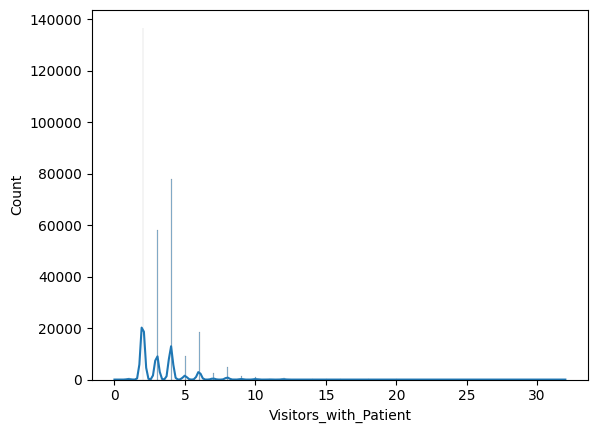

In [23]:
sns.histplot(df['Visitors_with_Patient'],kde=True)

In [24]:
x = pd.pivot_table(data=df,index='Age',columns='Stay',values='case_id',aggfunc='count')
x['total'] = x.sum(axis=1)
x = x.div(x['total'], axis=0)
x

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days,total
Age,,,,,,,,,,,,
0-10,0.097900,0.313409,0.238288,0.161551,0.029887,0.093053,0.004200,0.024717,0.013570,0.005654,0.017771,1.0
11-20,0.092459,0.318800,0.257786,0.159158,0.030477,0.085384,0.005321,0.020862,0.013183,0.004172,0.012396,1.0
21-30,0.084575,0.275998,0.279723,0.169299,0.034192,0.092422,0.006431,0.025079,0.013409,0.005562,0.013309,1.0
31-40,0.077167,0.248470,0.291699,0.171367,0.037173,0.102326,0.007935,0.028505,0.012508,0.007553,0.015296,1.0
41-50,0.074114,0.234892,0.281481,0.172257,0.039133,0.112896,0.008765,0.033433,0.013811,0.009037,0.020181,1.0
51-60,0.070804,0.234539,0.269355,0.176109,0.035590,0.118097,0.009274,0.035192,0.016141,0.010216,0.024683,1.0
61-70,0.065257,0.233859,0.268217,0.175853,0.035923,0.120916,0.009688,0.036555,0.017811,0.009838,0.026085,1.0
71-80,0.061634,0.222549,0.266278,0.179527,0.038496,0.123494,0.010466,0.038327,0.018753,0.010805,0.029671,1.0
81-90,0.053254,0.177000,0.243375,0.190764,0.047852,0.136866,0.014793,0.050682,0.027528,0.016851,0.041034,1.0


<Axes: xlabel='Admission_Deposit', ylabel='Count'>

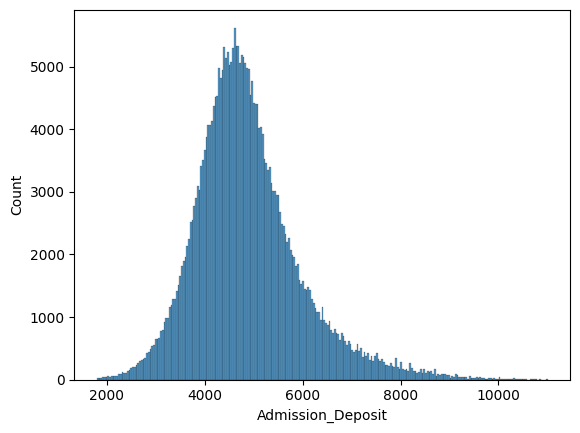

In [25]:
sns.histplot(df['Admission_Deposit'])

In [26]:
df.groupby('Stay')['Admission_Deposit'].mean()

Stay
0-10                  4615.667871
11-20                 4931.358065
21-30                 5026.906669
31-40                 4873.306010
41-50                 4888.903041
51-60                 4749.617996
61-70                 4844.482950
71-80                 4710.176406
81-90                 4587.864944
91-100                4717.868411
More than 100 Days    4650.187691
Name: Admission_Deposit, dtype: float64

In [ ]:
from ydata_profiling import ProfileReport
ProfileReport(df, title="Pandas Profiling Report", explorative=True)

<Axes: >

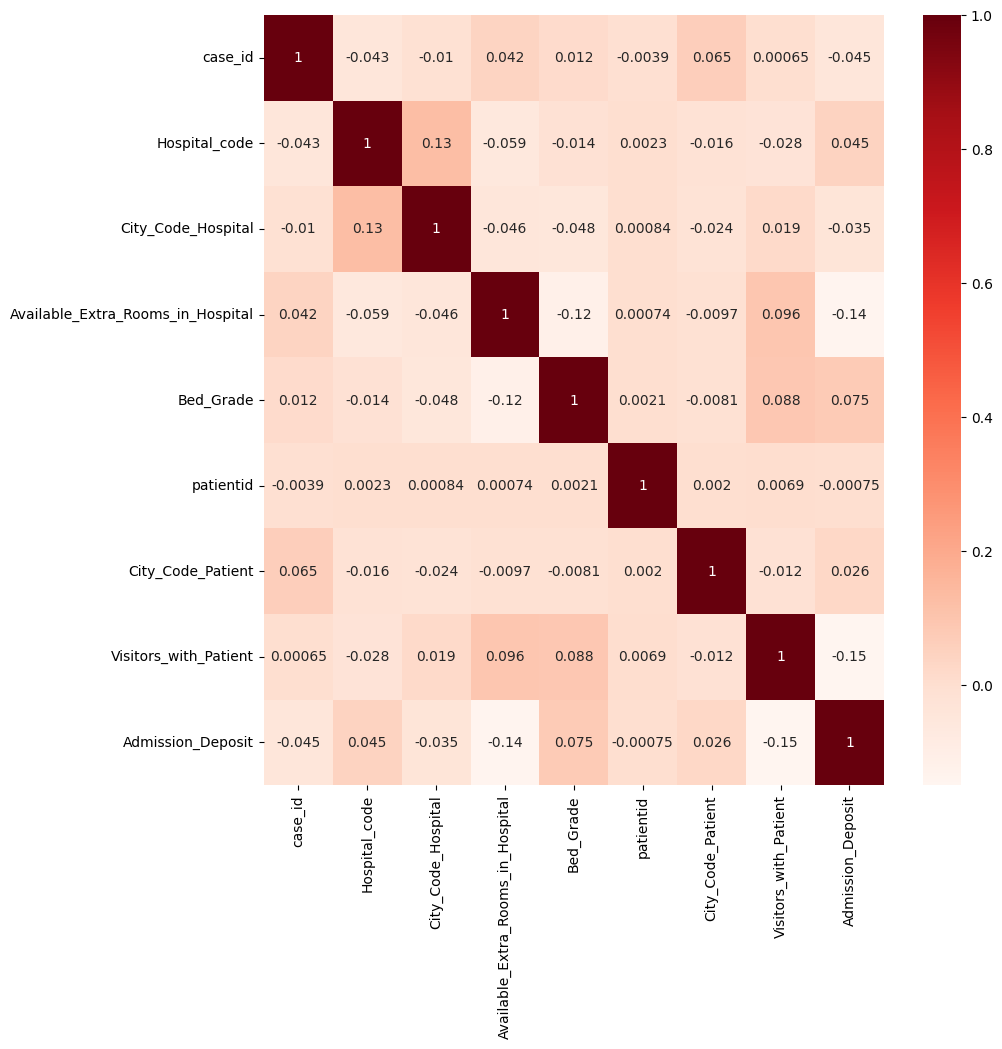

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(
    df[df.select_dtypes(include=['int64', 'float64']).columns.tolist()].corr(),
    annot=True,
    cmap='Reds'
)

## Feature Engineering

In [ ]:
#On basis of EDA observation

int_columns = list(df.drop(columns=['case_id','patientid','Admission_Deposit']).select_dtypes(include=['int','float']).columns)
df[int_columns] = df[int_columns].astype('object')
target_encoding_col = list(df.drop(columns='Stay').select_dtypes(include='object').columns)
std_scal_col = ['Admission_Deposit']

In [5]:
x = df.drop(columns='Stay')
y = df['Stay']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

In [32]:
from sklearn.utils.class_weight import  compute_sample_weight
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
preprocessed_y_train = le.fit_transform(y_train)
preprocessed_y_test = le.transform(y_test)

from sklearn.preprocessing import TargetEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('Target_encoding',TargetEncoder(),target_encoding_col),
    ('Standard_Scaler',StandardScaler(),std_scal_col)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Target_encoding', ...), ('Standard_Scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

In [ ]:
preprocessed_x_train = preprocessor.fit_transform(x_train,preprocessed_y_train)
preprocessed_x_test = preprocessor.transform(x_test) 

**XGBOOST**

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(objective='multi:softmax',
    num_class=len(np.unique(preprocessed_y_train)),
    
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    random_state=42,
    
    eval_metric='mlogloss'
)

In [ ]:
xgb.fit(preprocessed_x_train,preprocessed_y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [38]:
x_predict = xgb.predict(preprocessed_x_test)

from sklearn.metrics import classification_report
print(classification_report(preprocessed_y_test,x_predict))  

x_predict = xgb.predict(preprocessed_x_train)

from sklearn.metrics import classification_report
print(classification_report(preprocessed_y_train,x_predict))  

              precision    recall  f1-score   support

           0       0.41      0.16      0.23      2303
           1       0.43      0.67      0.53      8638
           2       0.45      0.23      0.31      5508
           3       0.29      0.00      0.00      1161
           4       0.42      0.51      0.46      3484
           5       0.00      0.00      0.00       288
           6       0.38      0.04      0.08       954
           7       0.34      0.19      0.24       450
           8       0.46      0.04      0.08       279
           9       0.59      0.44      0.51       670
          10       0.44      0.52      0.48      7645

    accuracy                           0.44     31380
   macro avg       0.38      0.26      0.26     31380
weighted avg       0.43      0.44      0.40     31380

              precision    recall  f1-score   support

           0       0.59      0.27      0.37     20947
           1       0.47      0.73      0.57     77678
           2       0.58 

In [39]:
xgb.save_model('Multiclass xgb.joblib')

C:\Users\kadam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\sklearn.py:1116: UserWarning: [11:56:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


In [26]:
# =====================================================
# RANDOMIZED SEARCH FOR MULTI-CLASS XGBOOST
# =====================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

# =====================================================
# SAMPLE WEIGHTS
# =====================================================

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=preprocessed_y_train
)

# =====================================================
# BASE MODEL
# =====================================================

xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)

# =====================================================
# PARAMETER DISTRIBUTIONS
# =====================================================

param_distributions = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1]
}

# =====================================================
# RANDOMIZED SEARCH
# =====================================================

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,   # Reduced from 50 to 20
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


In [27]:

# =====================================================
# TRAIN
# =====================================================

random_search.fit(
    preprocessed_x_train,
    preprocessed_y_train,
    sample_weight=sample_weight
)

# =====================================================
# BEST PARAMETERS
# =====================================================

print("\nBest Parameters:\n")
print(random_search.best_params_)

print("\nBest CV Score:\n")
print(random_search.best_score_)

# =====================================================
# BEST MODEL
# =====================================================

best_xgb = random_search.best_estimator_

# =====================================================
# PREDICTION
# =====================================================

y_pred = best_xgb.predict(preprocessed_x_test)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report:\n")
print(classification_report(preprocessed_y_test, y_pred))

y_pred = best_xgb.predict(preprocessed_x_train)
print("\nClassification Report:\n")
print(classification_report(preprocessed_y_train, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:

{'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}

Best CV Score:

0.3188321591880258

Classification Report:

              precision    recall  f1-score   support

           0       0.21      0.56      0.31      2303
           1       0.49      0.34      0.40      8638
           2       0.48      0.10      0.16      5508
           3       0.08      0.32      0.13      1161
           4       0.38      0.30      0.33      3484
           5       0.03      0.10      0.04       288
           6       0.15      0.22      0.18       954
           7       0.19      0.57      0.29       450
           8       0.07      0.22      0.10       279
           9       0.46      0.47      0.47       670
          10       0.46      0.35      0.40      7645

    accuracy                           0.31     31380
   macro avg  

**SVC**

In [40]:
from sklearn.svm import SVC
svc = SVC()

In [ ]:
svc.fit(preprocessed_x_train,preprocessed_y_train,sample_weight=sample_weight)

In [ ]:
predict_x = svc.predict(preprocessed_x_test)

from sklearn.metrics import classification_report
print(classification_report(preprocessed_y_test,predict_x))

## REAPPLY-Feature Engineering

In [35]:

target_encoding = ['Hospital_code','City_Code_Patient']
one_hot = ['Hospital_type_code','City_Code_Hospital','Hospital_region_code','Department','Ward_Type','Ward_Facility_Code','Bed_Grade','Type_of_Admission','Severity_of_Illness','Age']
min_max_scalar = ['Available_Extra_Rooms_in_Hospital','Admission_Deposit']
standard_scalar = ['Visitors_with_Patient']

df[target_encoding+one_hot] = df[target_encoding+one_hot].astype('object')

x = df.drop(columns="Stay")
y = df['Stay']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)



from sklearn.utils.class_weight import  compute_sample_weight
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

from sklearn.preprocessing import TargetEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer



preprocessor = ColumnTransformer([
    ('Target_encoder',TargetEncoder(),target_encoding),
    ('One_hot_encoding',OneHotEncoder(),one_hot),
    ('Standard_scaling',StandardScaler(),standard_scalar),
    ('Min_max_scaling',MinMaxScaler(),min_max_scalar)
])

processed_x_train = preprocessor.fit_transform(x_train,y_train)
processed_x_test = preprocessor.transform(x_test)

**USING XGBCLASSIFIER**

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    objective='multi:softprob',
    num_class=11,

    # START SMALL
    n_estimators=500,
    learning_rate=0.05,

    # TREE CONTROL
    max_depth=6,
    min_child_weight=3,

    # OVERFITTING CONTROL
    subsample=0.8,
    colsample_bytree=0.8,

    # REGULARIZATION
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=2,

    # SPEED
    tree_method='hist',
    device='cuda',  

    eval_metric='mlogloss',

    n_jobs=-1,
    random_state=42
)

In [38]:
xgb.fit(processed_x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [39]:
predicted_y = xgb.predict(processed_x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,predicted_y))


predicted_y = xgb.predict(processed_x_train)
from sklearn.metrics import classification_report
print(classification_report(y_train,predicted_y))

              precision    recall  f1-score   support

           0       0.40      0.16      0.23      2303
           1       0.45      0.51      0.47      7645
           2       0.43      0.68      0.53      8638
           3       0.45      0.22      0.30      5508
           4       0.21      0.00      0.01      1161
           5       0.42      0.52      0.46      3484
           6       0.00      0.00      0.00       288
           7       0.38      0.03      0.06       954
           8       0.35      0.21      0.26       450
           9       0.31      0.01      0.03       279
          10       0.56      0.44      0.49       670

    accuracy                           0.43     31380
   macro avg       0.36      0.25      0.26     31380
weighted avg       0.42      0.43      0.40     31380

              precision    recall  f1-score   support

           0       0.49      0.20      0.28     20947
           1       0.46      0.53      0.49     69450
           2       0.44 

**USING LINEARSVC**

In [10]:
from sklearn.svm import LinearSVC

svc = LinearSVC(
         C=1,
         max_iter=5000
     )

In [12]:
svc.fit(processed_x_train, y_train, sample_weight=sample_weight)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random

In [13]:
predicted_y = svc.predict(processed_x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,predicted_y))

              precision    recall  f1-score   support

           0       0.16      0.62      0.26      2303
           1       0.41      0.28      0.33      7645
           2       0.48      0.32      0.39      8638
           3       0.50      0.01      0.02      5508
           4       0.07      0.17      0.10      1161
           5       0.40      0.09      0.15      3484
           6       0.02      0.15      0.04       288
           7       0.12      0.02      0.04       954
           8       0.05      0.18      0.08       450
           9       0.04      0.19      0.07       279
          10       0.18      0.72      0.29       670

    accuracy                           0.24     31380
   macro avg       0.22      0.25      0.16     31380
weighted avg       0.39      0.24      0.24     31380



**USING LOGISTIC RESGRESSOR**

In [16]:
from sklearn.linear_model import  LogisticRegression
lg = LogisticRegression(max_iter=1000,n_jobs=-1)

In [17]:
lg.fit(processed_x_train, y_train, sample_weight=sample_weight)

C:\Users\kadam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
predicted_y = lg.predict(processed_x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,predicted_y))

              precision    recall  f1-score   support

           0       0.19      0.51      0.28      2303
           1       0.45      0.29      0.35      7645
           2       0.48      0.29      0.36      8638
           3       0.30      0.09      0.14      5508
           4       0.08      0.20      0.11      1161
           5       0.36      0.25      0.29      3484
           6       0.02      0.19      0.03       288
           7       0.14      0.09      0.11       954
           8       0.10      0.31      0.16       450
           9       0.04      0.24      0.07       279
          10       0.35      0.54      0.42       670

    accuracy                           0.26     31380
   macro avg       0.23      0.27      0.21     31380
weighted avg       0.36      0.26      0.28     31380



**USING RANDOM FOREST**

In [19]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(

         n_estimators=300,

         max_depth=20,

         min_samples_split=5,
         min_samples_leaf=2,

         max_features='sqrt',

         n_jobs=-1,

         random_state=42
     )

In [20]:
rfc.fit(processed_x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [21]:
predicted_y = rfc.predict(processed_x_test)
from sklearn.metrics import classification_report
print(classification_report(y_test,predicted_y))

predicted_y = rfc.predict(processed_x_train)
from sklearn.metrics import classification_report
print(classification_report(y_train,predicted_y))

C:\Users\kadam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kadam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kadam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

              precision    recall  f1-score   support

           0       0.44      0.11      0.17      2303
           1       0.43      0.49      0.46      7645
           2       0.42      0.69      0.52      8638
           3       0.42      0.23      0.29      5508
           4       0.00      0.00      0.00      1161
           5       0.40      0.52      0.45      3484
           6       0.00      0.00      0.00       288
           7       0.30      0.02      0.03       954
           8       0.53      0.04      0.08       450
           9       1.00      0.00      0.01       279
          10       0.63      0.40      0.49       670

    accuracy                           0.42     31380
   macro avg       0.42      0.23      0.23     31380
weighted avg       0.41      0.42      0.38     31380

              precision    recall  f1-score   support

           0       0.93      0.46      0.61     20947
           1       0.71      0.79      0.75     69450
           2       0.61 

**Using ANN**

In [26]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# 1. Compute sample weights on the FULL training set
train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Define the pipeline 
model_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        batch_size=1024,
        max_iter=50,          
        early_stopping=True,     # Enabled!
        validation_fraction=0.1, # FIX: Changed from 0.0 to 0.1 (default)
        n_iter_no_change=5,   
        verbose=True,
        random_state=42
    ))
])

# 3. Train using full training sets
model_pipeline.fit(processed_x_train, y_train, mlp__sample_weight=train_weights)

# 4. Predict
y_pred_prob = model_pipeline.predict_proba(processed_x_test)
y_pred = model_pipeline.predict(processed_x_test)


Iteration 1, loss = 2.03057522
Validation score: 0.295478
Iteration 2, loss = 1.89230995
Validation score: 0.300490
Iteration 3, loss = 1.85285519
Validation score: 0.314279
Iteration 4, loss = 1.82684393
Validation score: 0.316439
Iteration 5, loss = 1.80230791
Validation score: 0.319918
Iteration 6, loss = 1.78466482
Validation score: 0.317291
Iteration 7, loss = 1.76624843
Validation score: 0.315898
Iteration 8, loss = 1.74782243
Validation score: 0.316154
Iteration 9, loss = 1.72950713
Validation score: 0.320467
Iteration 10, loss = 1.71245400
Validation score: 0.317503
Iteration 11, loss = 1.69264753
Validation score: 0.319563
Iteration 12, loss = 1.67751051
Validation score: 0.313140
Iteration 13, loss = 1.65903368
Validation score: 0.314487
Iteration 14, loss = 1.63879139
Validation score: 0.313163
Iteration 15, loss = 1.62019752
Validation score: 0.313490
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.


**Using PCA IN XGBOOST**

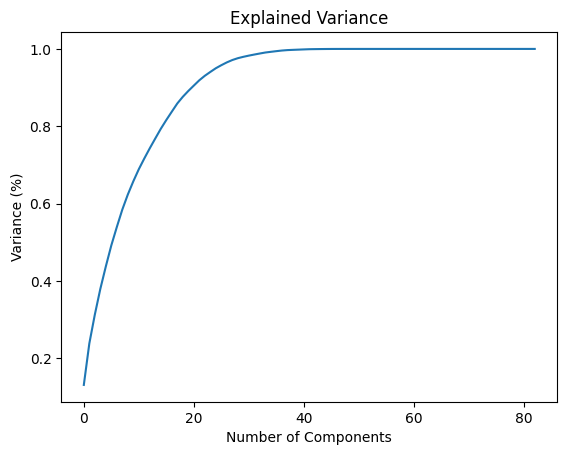

In [29]:
import matplotlib.pyplot as plt
import numpy as np

## getting the optimal number of pca
from sklearn.decomposition import PCA
pca = PCA()
principalComponents = pca.fit_transform(processed_x_train)
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)') #for each component
plt.title('Explained Variance')
plt.show()

In [30]:
np.where(np.cumsum(pca.explained_variance_ratio_)>0.99)

(array([33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
        50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
        67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]),)

In [32]:
from xgboost import XGBClassifier
pca = PCA(n_components=0.99, random_state=42)

processed_x_train_pca = pca.fit_transform(processed_x_train)
processed_x_test_pca = pca.transform(processed_x_test)

print("Original Shape :", processed_x_train.shape)
print("PCA Shape      :", processed_x_train_pca.shape)


xgb_model = XGBClassifier(

    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    objective='multi:softprob',

    eval_metric='mlogloss',

    tree_method='hist',

    random_state=42
)


Original Shape : (282413, 83)
PCA Shape      : (282413, 34)


In [33]:
xgb_model.fit(processed_x_train_pca,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [34]:
y_pred = xgb_model.predict(processed_x_test_pca)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.11      0.17      2303
           1       0.40      0.49      0.44      7645
           2       0.41      0.64      0.50      8638
           3       0.42      0.22      0.29      5508
           4       0.17      0.00      0.01      1161
           5       0.41      0.47      0.44      3484
           6       0.27      0.01      0.03       288
           7       0.31      0.06      0.10       954
           8       0.39      0.28      0.32       450
           9       0.43      0.11      0.17       279
          10       0.58      0.46      0.51       670

    accuracy                           0.41     31380
   macro avg       0.38      0.26      0.27     31380
weighted avg       0.40      0.41      0.38     31380



## Full - Final pipeline

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, TargetEncoder
from xgboost import XGBClassifier
from sklearn.preprocessing import TargetEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer



df = pd.read_csv('HealthCareAnalytics.csv')
df.replace({'Nov-20':'11-20'},inplace=True)


target_encoding = ['Hospital_code','City_Code_Patient']
one_hot = ['Hospital_type_code','City_Code_Hospital','Hospital_region_code','Department','Ward_Type','Ward_Facility_Code','Bed_Grade','Type_of_Admission','Severity_of_Illness','Age']
min_max_scalar = ['Available_Extra_Rooms_in_Hospital','Admission_Deposit']
standard_scalar = ['Visitors_with_Patient']

df[target_encoding+one_hot] = df[target_encoding+one_hot].astype('object')

x = df.drop(columns="Stay")
y = df['Stay']


from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)


from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

preprocessed_y_train = label_encoder.fit_transform(y_train)
preprocessed_y_test = label_encoder.transform(y_test)




# 1. Define separate sub-pipelines for columns requiring both imputation and transformation
target_encode_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(random_state=42))
])

one_hot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

min_max_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Median is robust to outliers
    ('scaler', MinMaxScaler())
])

standard_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# 2. Combine all sub-pipelines into the final ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('Target_encoder', target_encode_pipeline, target_encoding),
        ('One_hot_encoding', one_hot_pipeline, one_hot),
        ('Min_max_scaling', min_max_pipeline, min_max_scalar),
        ('Standard_scaling', standard_pipeline, standard_scalar)
    ]
)



# ==========================================
# 3. CREATE FINAL END-TO-END PIPELINE
# ==========================================
full_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('xgb', XGBClassifier(
        objective='multi:softmax',
        num_class=len(np.unique(preprocessed_y_train)),
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ))
])





In [3]:
# ==========================================
# 4. TRAIN AND PREDICT
# ==========================================
# The full pipeline automatically handles imputation, preprocessing, and training
full_pipeline.fit(x_train, preprocessed_y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Target_encoder', ...), ('One_hot_encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [4]:
y_pred = full_pipeline.predict(x_test)
from sklearn.metrics import classification_report
print(classification_report(preprocessed_y_test,y_pred))

y_pred = full_pipeline.predict(x_train)
from sklearn.metrics import classification_report
print(classification_report(preprocessed_y_train,y_pred))

              precision    recall  f1-score   support

           0       0.39      0.17      0.23      2320
           1       0.43      0.51      0.47      7765
           2       0.43      0.66      0.52      8748
           3       0.44      0.23      0.30      5540
           4       0.22      0.00      0.00      1132
           5       0.42      0.51      0.46      3628
           6       0.00      0.00      0.00       272
           7       0.35      0.03      0.05      1042
           8       0.33      0.20      0.25       463
           9       0.61      0.04      0.07       284
          10       0.55      0.43      0.48       650

    accuracy                           0.43     31844
   macro avg       0.38      0.25      0.26     31844
weighted avg       0.42      0.43      0.39     31844

              precision    recall  f1-score   support

           0       0.49      0.21      0.30     21284
           1       0.47      0.54      0.50     70374
           2       0.45 

In [5]:
import joblib
joblib.dump(full_pipeline, 'Healthcare_Multiclass_pipeline.joblib')
print("Pipeline saved successfully!")

Pipeline saved successfully!


In [6]:
x = df.drop(columns='Stay')
y = df['Stay']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
preprocessed_y_train = le.fit_transform(y_train)
preprocessed_y_test = le.transform(y_test)

In [9]:
import joblib

# Load the entire pipeline back into memory
loaded_pipeline = joblib.load('Healthcare_Multiclass_pipeline.joblib')

# It is instantly ready for predictions on raw data
y_pred = loaded_pipeline.predict(x_test)

from sklearn.metrics import classification_report
print(classification_report(preprocessed_y_test,y_pred))

              precision    recall  f1-score   support

           0       0.39      0.17      0.23      2320
           1       0.43      0.51      0.47      7765
           2       0.43      0.66      0.52      8748
           3       0.44      0.23      0.30      5540
           4       0.22      0.00      0.00      1132
           5       0.42      0.51      0.46      3628
           6       0.00      0.00      0.00       272
           7       0.35      0.03      0.05      1042
           8       0.33      0.20      0.25       463
           9       0.61      0.04      0.07       284
          10       0.55      0.43      0.48       650

    accuracy                           0.43     31844
   macro avg       0.38      0.25      0.26     31844
weighted avg       0.42      0.43      0.39     31844

